# Advanced Analytics & Risk Metrics

## Objective

The objective of this notebook is to perform advanced mutual fund analytics beyond traditional performance metrics. This analysis includes risk measurement using Value at Risk (VaR) and Conditional Value at Risk (CVaR), rolling Sharpe ratio analysis, investor behavior analysis, SIP continuity, fund recommendation, and portfolio concentration analysis.

These metrics provide deeper insights into portfolio risk, investor patterns, and fund quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR)

## Objective

Estimate the downside risk of each mutual fund using historical daily returns.

### Metrics

**Value at Risk (VaR 95%)**

Represents the maximum expected daily loss with 95% confidence.

Formula

VaR = 5th Percentile of Daily Returns

**Conditional Value at Risk (CVaR)**

Represents the average loss on days where returns fall below the VaR threshold.

Formula

CVaR = Mean(Returns < VaR)

Both metrics help investors understand extreme downside risk.

In [7]:
nav_df = pd.read_csv(
    "../data/processed/nav_daily_returns.csv"
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
nav_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   amfi_code     46000 non-null  int64  
 1   date          46000 non-null  object 
 2   nav           46000 non-null  float64
 3   daily_return  45960 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.4+ MB


In [11]:
results = []

for amfi, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    var95 = np.percentile(returns,5)

    cvar95 = returns[returns <= var95].mean()

    results.append({

        "amfi_code":amfi,

        "VaR_95":var95,

        "CVaR_95":cvar95

    })

var_df = pd.DataFrame(results)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [13]:
var_df.sort_values(
    "VaR_95"
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [15]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

## Insight

Historical Value at Risk (VaR) estimates the potential daily loss under normal market conditions with 95% confidence.

Conditional Value at Risk (CVaR) measures the average loss during the worst 5% of trading days, providing a better estimate of tail risk.

Funds with more negative VaR and CVaR values exhibit greater downside risk and may be more vulnerable during volatile market periods.

# Task 2: Rolling 90-Day Sharpe Ratio

## Objective

Analyze how the risk-adjusted performance of mutual funds changes over time using a rolling 90-day Sharpe Ratio.

### Formula

Rolling Sharpe Ratio = (Rolling Mean Return / Rolling Standard Deviation) × √252

A 90-day rolling window is used to observe changes in fund performance under varying market conditions. Higher Sharpe Ratio values indicate better risk-adjusted returns.

In [19]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

In [21]:
rolling_results = []

for amfi, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["Rolling_Sharpe"] = (
        group["daily_return"]
        .rolling(90)
        .mean()
        /
        group["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_results.append(group)

rolling_df = pd.concat(rolling_results)

rolling_df.head()

,amfi_code,date,nav,daily_return,Rolling_Sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [25]:
sharpe_df = pd.read_csv("../reports/sharpe_ratio.csv")

top5 = sharpe_df.head(5)["amfi_code"].tolist()

In [27]:
top5 = (
    sharpe_df
    .head(5)["amfi_code"]
    .tolist()
)

top5

[148567, 120843, 148569, 119551, 120505]

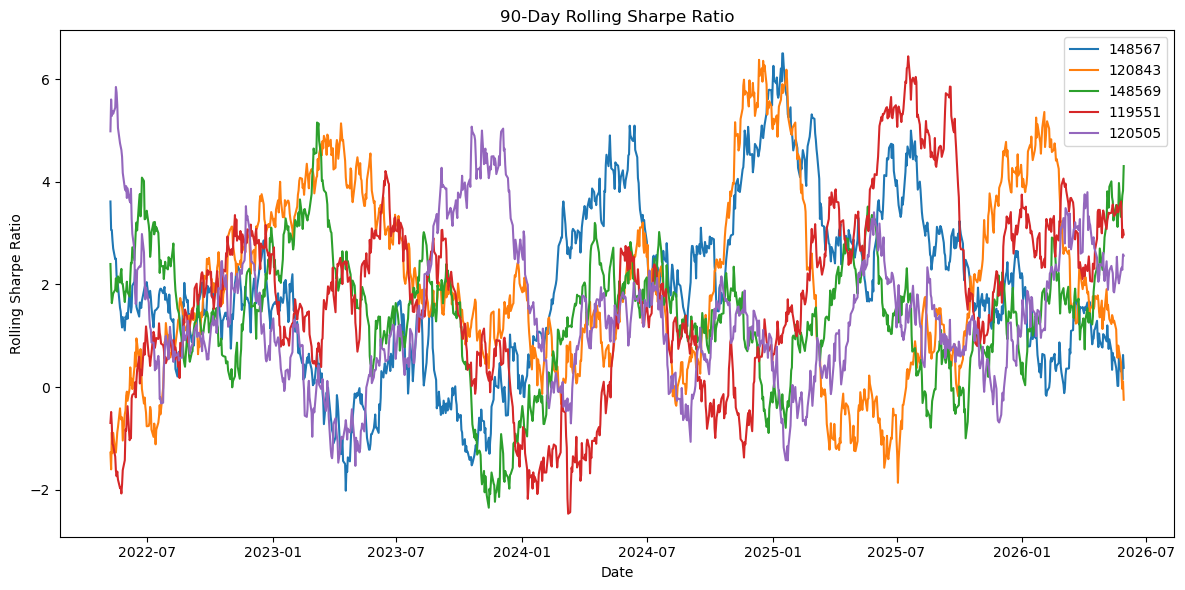

In [29]:
plt.figure(figsize=(12,6))

for fund in top5:

    temp = rolling_df[
        rolling_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["Rolling_Sharpe"],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Rolling Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.show()

In [31]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight

The rolling 90-day Sharpe Ratio captures the evolution of risk-adjusted returns over time.

Funds with consistently higher rolling Sharpe Ratios demonstrate stable performance, while significant fluctuations indicate changing market conditions or increased portfolio risk.

Comparing the top-performing funds helps identify those with sustained performance consistency rather than isolated periods of high returns.

# Task 3: Investor Cohort Analysis

## Objective

Analyze investor behavior by grouping investors based on the year of their first transaction.

### Metrics

- Cohort Year (First Transaction Year)
- Average Investment Amount
- Total Investment
- Most Preferred Fund (AMFI Code)

Cohort analysis helps understand how different groups of investors behave over time and identifies investment trends across various entry years.

In [41]:
transactions_df = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

transactions_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [43]:
transactions_df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [45]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  object 
 1   transaction_date    32778 non-null  object 
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  object 
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  object 
 6   city                32778 non-null  object 
 7   city_tier           32778 non-null  object 
 8   age_group           32778 non-null  object 
 9   gender              32778 non-null  object 
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  object 
 12  kyc_status          32778 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 3.3+ MB


In [48]:
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"]
)

In [50]:
transactions_df["cohort_year"] = (
    transactions_df
    .groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

transactions_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [52]:
cohort_summary = (
    transactions_df
    .groupby("cohort_year")
    .agg(
        Avg_Investment=("amount_inr","mean"),
        Total_Investment=("amount_inr","sum"),
        Total_Investors=("investor_id","nunique")
    )
)

cohort_summary

,Avg_Investment,Total_Investment,Total_Investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [54]:
preferred_fund = (
    transactions_df
    .groupby(["cohort_year","amfi_code"])
    .size()
    .reset_index(name="Transactions")
)

preferred_fund = (
    preferred_fund
    .sort_values(
        ["cohort_year","Transactions"],
        ascending=[True,False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

preferred_fund

,cohort_year,amfi_code,Transactions
0,2024,148568,874
1,2025,119599,12


In [56]:
cohort_report = cohort_summary.merge(
    preferred_fund[["cohort_year","amfi_code"]],
    on="cohort_year"
)

cohort_report.rename(
    columns={
        "amfi_code":"Preferred_Fund"
    },
    inplace=True
)

cohort_report

,cohort_year,Avg_Investment,Total_Investment,Total_Investors,Preferred_Fund
0,2024,107422.541832,3491125187,4803,148568
1,2025,109158.577061,30455243,197,119599


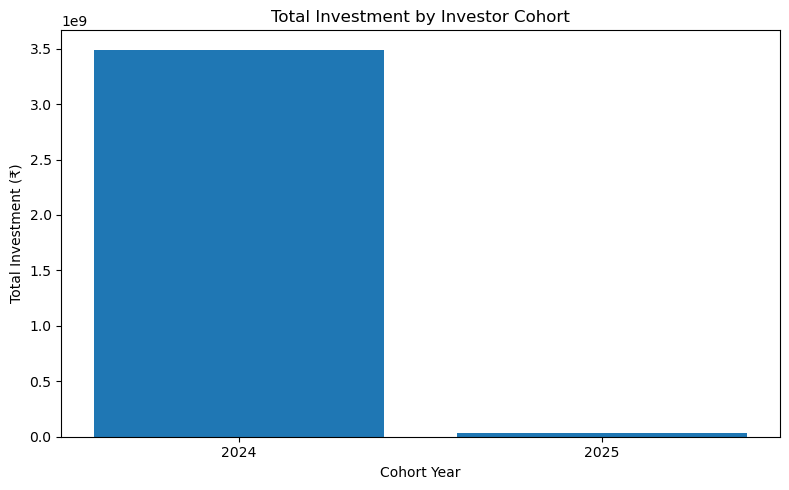

In [58]:
plt.figure(figsize=(8,5))

plt.bar(
    cohort_report["cohort_year"].astype(str),
    cohort_report["Total_Investment"]
)

plt.title("Total Investment by Investor Cohort")

plt.xlabel("Cohort Year")

plt.ylabel("Total Investment (₹)")

plt.tight_layout()

plt.show()


In [60]:
plt.savefig("../reports/cohort_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [62]:
cohort_report.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

## Insight

Investor cohort analysis groups investors according to the year of their first investment transaction.

The analysis shows the average investment amount, cumulative investment, total number of investors, and the most preferred mutual fund within each cohort.

These insights help identify investor participation trends and fund preferences across different investment cohorts.

In [67]:
transactions_df["transaction_date"].dt.year.value_counts()

transaction_date
2024    23210
2025     9568
Name: count, dtype: int64

# Task 4: SIP Continuity Analysis

## Objective

Analyze the continuity of SIP investments by measuring the average time gap between consecutive SIP transactions for each investor.

### Criteria

- Consider investors with at least 6 SIP transactions.
- Compute the average gap (in days) between consecutive SIP dates.
- Flag investors with an average gap greater than 35 days as **At Risk**.

This analysis helps identify investors who may discontinue their SIP investments.

In [70]:
sip_df = transactions_df[
    transactions_df["transaction_type"] == "Sip"
].copy()

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [72]:
sip_df["transaction_date"] = pd.to_datetime(
    sip_df["transaction_date"]
)

sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

In [74]:
eligible = (
    sip_df.groupby("investor_id")
    .filter(lambda x: len(x) >= 6)
)

eligible.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024
12003,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024
28749,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024


In [76]:
eligible["gap_days"] = (
    eligible.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

eligible.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,Sip,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,Sip,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,Sip,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,Sip,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,Sip,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


In [78]:
sip_gap = (
    eligible.groupby("investor_id")
    .agg(
        Avg_Gap_Days=("gap_days", "mean"),
        Total_SIP=("transaction_date", "count")
    )
    .reset_index()
)

sip_gap.head()

,investor_id,Avg_Gap_Days,Total_SIP
0,INV000004,85.400000,6
1,INV000008,70.400000,6
2,INV000010,64.800000,6
3,INV000011,40.166667,7
4,INV000012,57.000000,8


In [80]:
sip_gap["Status"] = np.where(
    sip_gap["Avg_Gap_Days"] > 35,
    "At Risk",
    "Active"
)

sip_gap.head()

,investor_id,Avg_Gap_Days,Total_SIP,Status
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk


In [82]:
sip_gap["Status"].value_counts()

Status
At Risk    1332
Active       30
Name: count, dtype: int64

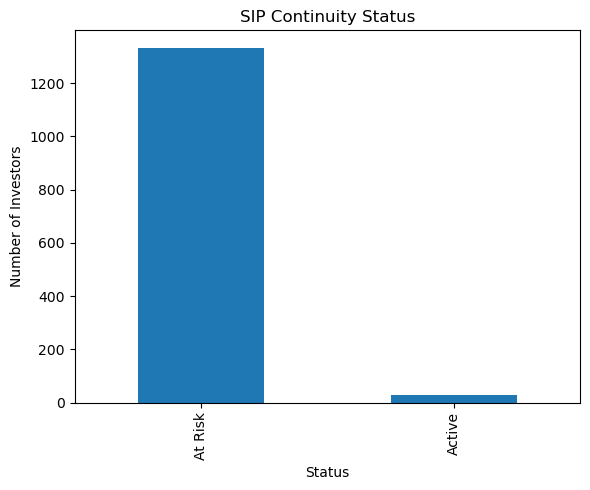

In [84]:
plt.figure(figsize=(6,5))

sip_gap["Status"].value_counts().plot(kind="bar")

plt.title("SIP Continuity Status")

plt.xlabel("Status")

plt.ylabel("Number of Investors")

plt.tight_layout()

plt.savefig(
    "../reports/sip_continuity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [86]:
sip_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

## Insight

SIP continuity analysis measures investor discipline by evaluating the average interval between consecutive SIP transactions.

Investors with an average gap greater than 35 days are classified as **At Risk**, indicating possible discontinuation or irregular investment behavior.

This analysis helps fund managers identify investors who may require engagement or reminders to maintain investment continuity.

# Task 5: Simple Fund Recommender

## Objective

Build a simple mutual fund recommendation system based on an investor's risk appetite.

### Inputs

- Low Risk
- Moderate Risk
- High Risk

### Recommendation Criteria

For each risk category, recommend the top 3 mutual funds with the highest Sharpe Ratio.

The recommender helps investors identify efficient funds based on their preferred level of investment risk.

In [90]:
scheme_df = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

scheme_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [92]:
recommend_df = scheme_df.merge(
    sharpe_df,
    on="amfi_code"
)

recommend_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,Sharpe_Ratio
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,1.208267
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,0.953279
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,0.945308
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,-0.057187
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,-0.226575


In [94]:
recommend_df["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [96]:
def recommend_funds(risk):

    result = (
        recommend_df[
            recommend_df["risk_grade"] == risk
        ]
        .sort_values(
            "Sharpe_Ratio",
            ascending=False
        )
        [
            [
                "scheme_name",
                "fund_house",
                "Sharpe_Ratio",
                "return_3yr_pct"
            ]
        ]
        .head(3)
    )

    return result

In [98]:
recommend_funds("Low")

,scheme_name,fund_house,Sharpe_Ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,0.495723,7.68
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,-0.088747,6.18
4,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,-0.226575,6.07


In [100]:
recommend_funds("Moderate")

,scheme_name,fund_house,Sharpe_Ratio,return_3yr_pct
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,1.448291,14.81
0,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,1.208267,12.36
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,1.081659,14.00


In [102]:
recommend_funds("High")

,scheme_name,fund_house,Sharpe_Ratio,return_3yr_pct
36,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,1.234930,13.58
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,1.180101,18.08
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,1.132122,17.16


## Insight

The fund recommender suggests the top three mutual funds based on the investor's risk appetite.

Funds are ranked using the Sharpe Ratio, ensuring recommendations prioritize superior risk-adjusted returns while matching the selected risk category.

This simple rule-based recommendation system can assist investors in identifying suitable mutual fund schemes.

# Task 6: Sector HHI (Herfindahl-Hirschman Index) Concentration Analysis

## Objective

Measure the concentration of sector allocation within each mutual fund portfolio using the Herfindahl-Hirschman Index (HHI).

### Formula

HHI = Σ (Sector Weight²)

Where sector weights are expressed as proportions.

### Interpretation

- Lower HHI → Well-diversified portfolio
- Higher HHI → Concentrated portfolio

This metric helps evaluate the diversification level of equity mutual funds.

In [105]:
holdings_df = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

holdings_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [107]:
holdings_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [109]:
holdings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [112]:
holdings_df["weight"] = holdings_df["weight_pct"] / 100

In [114]:
hhi_df = (
    holdings_df
    .groupby("amfi_code")
    .apply(lambda x: (x["weight"] ** 2).sum())
    .reset_index(name="HHI")
)

hhi_df.head()

C:\Users\Rahul\AppData\Local\Temp\ipykernel_11872\1953307403.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["weight"] ** 2).sum())


,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [116]:
hhi_df.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


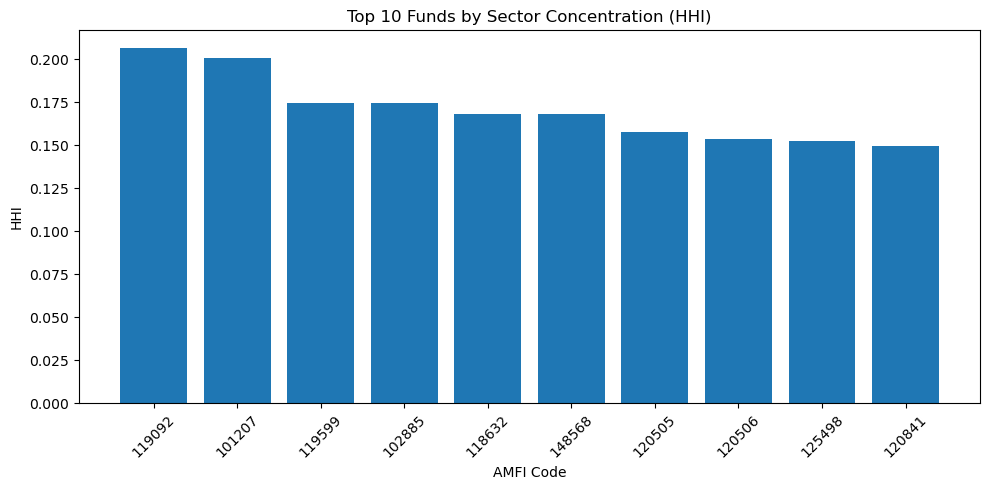

In [118]:
top10 = (
    hhi_df
    .sort_values(
        "HHI",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["HHI"]
)

plt.title("Top 10 Funds by Sector Concentration (HHI)")

plt.xlabel("AMFI Code")

plt.ylabel("HHI")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [120]:
hhi_df.to_csv(
    "../reports/sector_hhi.csv",
    index=False
)

## Insight

The Herfindahl-Hirschman Index (HHI) measures the degree of portfolio concentration across sectors.

Funds with higher HHI values allocate a larger proportion of assets to fewer sectors, making them more concentrated and potentially more sensitive to sector-specific risks.

Conversely, lower HHI values indicate better sector diversification, which may help reduce portfolio risk.

# Advanced Insights

1. Historical VaR and CVaR identify the funds with the highest downside risk during adverse market conditions.

2. Rolling 90-day Sharpe Ratio reveals that risk-adjusted performance changes over time, highlighting periods of market volatility and recovery.

3. Investor cohort analysis indicates differences in investment behaviour across cohorts, with newer cohorts showing increasing participation.

4. SIP continuity analysis helps identify investors at risk of discontinuing their SIP investments, enabling proactive investor engagement.

5. Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) highlights funds with highly concentrated portfolios and those with better sector diversification.